# Notebook 35 — Unified ENSO-displacement test: index vs supervised vs SSL vs NSV (BSISO + MJO)

**Why this notebook exists (Session 62, 2026-09-23).** Every earlier ENSO-displacement z-score was computed
under its own configuration (different days, bins, filters, nulls, units — see the inventory table in
`results/conversation_log.md`, Session 62b). The indices themselves were only tested once (RMM, nb16,
z = 4.10) and the APEC BSISO index never. This notebook recomputes the core representations **on one
footing** and adds the index rows, so the z-scores can finally be compared.

**Decisions locked (user, Session 62):**

| | Decision |
|---|---|
| Index "encoder" | none needed — the index PCs *are* a 2-D linear encoder. Both the **official PCs** (APEC BSISO1, BoM RMM) and an **own-EOF on the same ERA5 fields the nets see** (BSISO: computed here; MJO: `mjo_rmm_own_pcs.npy` from nb24) |
| Null | **year-level permutation is the headline** (whole ENSO years swapped); the legacy day-level shuffle is kept for continuity |
| Days | **active only** (amplitude >= 1) for BSISO *and* MJO |
| Where | this one notebook, CPU only, no retraining — it reads the saved embeddings |

**Held fixed for every representation (headline configuration):**
1. **Same dates** — the intersection of all core representations' days (z grows ~sqrt(N), so this matters).
2. **Same bins** — the official index phase (1-8). Works for NSV (4-D / 7-D, no own angle) and makes the
   EN/LN day groups identical across representations, so only the geometry differs.
3. **Whitened latent** — the statistic is computed after `(Z - mean) C^{-1/2}`, i.e. in Mahalanobis units.
   This makes z invariant to any invertible linear re-parametrisation of a latent (rotation, axis scaling),
   so a 2-D crescent and a 2-D ring are measured the same way. Trade-off for D > 2: whitening weights every
   direction equally, so if a latent's ENSO signal sits in a few of many dims, the low-variance noise dims
   dilute it. In a synthetic 7-D test, z was 12.0 in raw units and 3.5 whitened. Always read the NSV rows
   together with the `raw` sensitivity column.
4. **Same statistic** as every earlier notebook: mean over phases of ||centroid(EN) - centroid(LN)||,
   phases with < 3 EN or < 3 LN days skipped.

**Sensitivity configurations** (same function, one thing changed each): `native` (each representation's own
active days), `raw` (no whitening), `legacy` (native days, raw units, the original day filter — to check we
reproduce the logged numbers), `ownsector` (2-D latents binned by their own angle, the nb16 convention).

**Outputs** → `results/enso_displacement_unified/`: `zscores_all.csv`, `zscores_headline.csv`,
`per_phase_headline.csv`, `enso_displacement_unified.png`, `summary.md`, `bsiso_own_pcs.npz`.

## Cell 1 — Setup

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'
BSISO_PROC  = f'{PROJECT_DIR}/data/processed'
BSISO_RAW   = f'{PROJECT_DIR}/data/raw'
NSV_B_DIR   = f'{PROJECT_DIR}/nsv'
MJO_DIR     = f'{PROJECT_DIR}/MJO'
MJO_PROC    = f'{MJO_DIR}/data/processed'
OUT_DIR     = f'{PROJECT_DIR}/results/enso_displacement_unified'
os.makedirs(OUT_DIR, exist_ok=True)

# ---- decisions locked 2026-09-23 (Session 62) ----
AMP_MIN      = 1.0    # active days only, BSISO and MJO alike
N_PERM       = 2000   # permutations per null
MIN_PER_CELL = 3      # a phase counts only with >= 3 EN and >= 3 LN days (as in every earlier notebook)
SEED         = 42
RUN_SELFTEST = True   # Cell 3: synthetic check of the nulls (~15 s, no Drive data)

warnings.filterwarnings('ignore', message='Mean of empty slice')
warnings.filterwarnings('ignore', message='Degrees of freedom')
print('Output dir:', OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output dir: /content/drive/MyDrive/BSISO_SSL_Project/results/enso_displacement_unified


## Cell 2 — The test (one function for every representation)

**Statistic** (unchanged from nb05/08/14/15/16/20/23): for each phase p, `d_p = ||mean(Z | p, El Nino) - mean(Z | p, La Nina)||`;
the statistic is the mean of `d_p` over phases with >= 3 EN and >= 3 LN days.

**Three nulls:**
- **day** (legacy): ENSO labels shuffled independently across days. Ignores that the label is fixed for a
  whole year (BSISO: JJA Nino-3.4) or changes slowly month to month (MJO), and that latents are
  autocorrelated. The null comes out too narrow, so z is inflated, and slow latents are inflated the most.
- **year** (headline): whole ENSO years are swapped. A day in ENSO-year *b*, calendar month *s* gets the label
  that year pi(*b*) had in month *s*. Blocks are calendar years for BSISO (MJJAS lies inside one year) and
  June-May ENSO years for MJO. Only complete blocks are used. Swapping whole years keeps each year's days
  together, so autocorrelation and year-to-year drift can't pass as signal. Keeping each label's calendar
  month means a latent that only encodes the season can't either.
- **shift** (robustness): the ENSO-year label sequence is shifted cyclically by k = 1 ... n_blocks-1 whole years.
  Unlike the year swap, this also keeps ENSO's clustering across neighbouring years (multi-year La Nina etc.).

z = (obs - mean(null)) / sd(null); p = (1 + #null >= obs) / (1 + n_null); `ratio` = obs / mean(year-null) is
an effect size that does not grow with N.

**Known limit (found while testing this notebook on synthetic data).** No permutation null is exact for a latent
that drifts over *decades* while ENSO years cluster in time. In the worst synthetic case (a latent that is mostly a
random walk), the year swap still gave p < 0.05 in 30% of no-signal runs, and the shift in 15%. The day shuffle
gave z around 28. `slow_frac` in the tables, the share of a latent's variance that sits in year-to-year means,
flags where this matters. For an iid latent it is about n_years / N (under 0.01). If a representation has a large
`slow_frac`, read its z_year and z_shift as upper bounds.

In [11]:
CAT_CODE = {'El Nino': 0, 'La Nina': 1}          # anything else (Neutral, NaN) -> 2 = not used by the statistic

def cat_codes(values):
    return np.array([CAT_CODE.get(v, 2) for v in values], dtype=np.int64)

def whiten(Z):
    """(Z - mean) C^{-1/2}: Euclidean distance afterwards = Mahalanobis distance, so the statistic is
    unchanged by any invertible linear re-parametrisation of the latent."""
    Zc = Z - Z.mean(0)
    w, V = np.linalg.eigh(np.atleast_2d(np.cov(Zc, rowvar=False)))
    keep = w > w.max() * 1e-9
    return Zc @ V[:, keep] / np.sqrt(w[keep])

def phase_displacement(Z, phase, cat):
    """||centroid(EN) - centroid(LN)|| for phases 1..8; NaN where a cell has < MIN_PER_CELL days."""
    m = cat < 2
    key = (phase[m] - 1) * 2 + cat[m]                       # 0..15 = (phase, EN/LN)
    cnt = np.bincount(key, minlength=16)
    S = np.stack([np.bincount(key, weights=Z[m, j], minlength=16) for j in range(Z.shape[1])], 1)
    C = S / np.maximum(cnt, 1)[:, None]
    d = np.linalg.norm(C[0::2] - C[1::2], axis=1)
    ok = (cnt[0::2] >= MIN_PER_CELL) & (cnt[1::2] >= MIN_PER_CELL)
    return np.where(ok, d, np.nan)

def displacement_test(Z, phase, cat, block, slot, table, n_perm=N_PERM, seed=SEED):
    """Observed statistic + day, year (swap) and shift permutation nulls (see markdown above)."""
    rng = np.random.default_rng(seed)
    nb = table.shape[0]
    d_obs = phase_displacement(Z, phase, cat)
    obs = np.nanmean(d_obs)
    out = {'obs': obs, 'd_obs': d_obs}
    draws = {'day':   (lambda k: rng.permutation(cat),                  n_perm),
             'year':  (lambda k: table[rng.permutation(nb)[block], slot], n_perm),
             'shift': (lambda k: table[(block + k + 1) % nb, slot],     nb - 1)}
    for name, (draw, n_draw) in draws.items():
        D = np.array([phase_displacement(Z, phase, draw(k)) for k in range(n_draw)])
        null = np.nanmean(D, 1)
        null = null[np.isfinite(null)]
        mu, sd = null.mean(), null.std()
        out.update({f'null_{name}_mu': mu, f'null_{name}_sd': sd,
                    f'z_{name}': (obs - mu) / (sd + 1e-12),
                    f'p_{name}': (1 + np.sum(null >= obs)) / (1 + len(null)),
                    f'd_null_{name}': np.nanmean(D, 0)})
    out['ratio_year'] = obs / out['null_year_mu']
    return out

def slow_fraction(Zw, block):
    """Share of a whitened latent's variance carried by its ENSO-year block means (0 = none)."""
    Zc = Zw - Zw.mean(0)
    n = np.bincount(block)
    M = np.stack([np.bincount(block, weights=Zc[:, j]) for j in range(Zc.shape[1])], 1) / np.maximum(n, 1)[:, None]
    return float((n[:, None] * M ** 2).sum() / (Zc ** 2).sum())

def build_blocks(meta, block_start_month):
    """Adds `block_i` (index of the ENSO-year block, -1 if the block is incomplete) and `slot`
    (calendar month - 1) to `meta`, and returns the (n_blocks, 12) label table the year-level null
    draws from. block_start_month = 1 -> calendar years (BSISO); 6 -> June-May ENSO years (MJO)."""
    meta = meta.copy()
    d = meta.index
    yr = np.asarray(d.year - (d.month < block_start_month).astype(int))
    slot = np.asarray(d.month - 1)
    codes = cat_codes(meta['enso'].values)
    blocks = np.unique(yr)
    bi = np.searchsorted(blocks, yr)
    n_lab = pd.DataFrame({'b': bi, 's': slot, 'c': codes}).groupby(['b', 's'])['c'].nunique()
    if n_lab.max() > 1:
        print(f'   WARNING: ENSO label varies inside {int((n_lab > 1).sum())} (block, month) cells; '
              'the table keeps the last value')
    table = np.full((len(blocks), 12), 2, np.int64)
    covered = np.zeros((len(blocks), 12), bool)
    table[bi, slot] = codes
    covered[bi, slot] = True
    months = np.unique(slot)
    complete = covered[:, months].all(1)
    new_i = np.full(len(blocks), -1); new_i[complete] = np.arange(complete.sum())
    meta['block_i'] = new_i[bi]
    meta['slot'] = slot
    print(f'   ENSO-year blocks: {complete.sum()} complete of {len(blocks)} '
          f'({blocks[complete][0]}-{blocks[complete][-1]}); months used {sorted(months + 1)}')
    return meta, table[complete], blocks[complete]

print('Test functions ready.')

Test functions ready.


## Cell 3 — Self-test on synthetic data (no Drive data needed)

Four synthetic latents on a 30-year daily record with an MJO-like phase clock and monthly ENSO labels
(El Nino labelled Oct-Mar, La Nina Jul-Dec, so the two differ in calendar timing, as real events do):

| case | what the latent contains | expected z_day | expected z_year |
|---|---|---|---|
| A | a genuine within-phase EN/LN shift | high | high |
| B | no ENSO information | ~0 | ~0 |
| C | only the seasonal cycle (no ENSO) | **high (false positive)** | ~0 |
| D | a random year-to-year offset unrelated to ENSO | **high (false positive)** | ~0 |

C and D are the two ways a day-level null can report ENSO signal that isn't there.

In [12]:
def selftest(n_perm=500):
    rng = np.random.default_rng(0)
    dates = pd.date_range('1980-06-01', '2010-05-31', freq='D')          # 30 complete Jun-May years
    n = len(dates)
    yr = np.asarray(dates.year - (dates.month < 6).astype(int)); yrs = np.unique(yr); iy = np.searchsorted(yrs, yr)
    state = rng.choice([0, 1, 2], len(yrs), p=[.3, .3, .4])                  # EN / LN / neutral year
    en_on = np.isin(dates.month, [10, 11, 12, 1, 2, 3]); ln_on = np.isin(dates.month, [7, 8, 9, 10, 11, 12])
    cat = np.full(n, 2); cat[(state[iy] == 0) & en_on] = 0; cat[(state[iy] == 1) & ln_on] = 1
    theta = 2 * np.pi * np.arange(n) / 48 + rng.normal(0, .3, n)             # ~48-day phase clock
    phase = (np.floor((np.degrees(theta) % 360) / 45).astype(int) % 8) + 1
    ring = np.c_[np.cos(theta), np.sin(theta)] * (1.5 + .3 * rng.standard_normal(n))[:, None]
    doy = np.asarray(dates.dayofyear)
    meta = pd.DataFrame({'phase': phase, 'enso': np.array(['El Nino', 'La Nina', 'Neutral'])[cat]}, index=dates)
    meta, table, _ = build_blocks(meta, block_start_month=6)
    shift = np.c_[0.15 * ((cat == 0).astype(float) - (cat == 1)), np.zeros(n)]
    cases = {'A  true ENSO shift':        ring + shift,
             'B  no ENSO signal':         ring,
             'C  season only':            ring + .6 * np.c_[np.cos(2*np.pi*doy/365.25), np.sin(2*np.pi*doy/365.25)],
             'D  year-to-year drift only': ring + .3 * rng.standard_normal((len(yrs), 2))[iy]}
    rows = []
    for name, Z in cases.items():
        r = displacement_test(whiten(Z), phase, cat, meta['block_i'].values, meta['slot'].values, table, n_perm=n_perm)
        rows.append({'case': name, 'z_day': r['z_day'], 'z_year': r['z_year'], 'p_year': r['p_year'],
                     'z_shift': r['z_shift'], 'slow_frac': slow_fraction(whiten(Z), meta['block_i'].values)})
    st = pd.DataFrame(rows).set_index('case')
    print(st.round(2).to_string())
    ok = (st.loc['A  true ENSO shift', 'z_year'] > 3 and abs(st.loc['B  no ENSO signal', 'z_year']) < 3
          and st.loc['C  season only', 'z_day'] > 3 and st.loc['C  season only', 'z_year'] < 3
          and st.loc['D  year-to-year drift only', 'z_day'] > 3 and st.loc['D  year-to-year drift only', 'z_year'] < 3)
    print('\nSELF-TEST', 'PASSED' if ok else 'FAILED - do not trust the tables below', '\n')
    return st

if RUN_SELFTEST:
    selftest_table = selftest()

   ENSO-year blocks: 30 complete of 30 (1980-2009); months used [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
                            z_day  z_year  p_year  z_shift  slow_frac
case                                                                 
A  true ENSO shift          24.54    9.66    0.00    12.75       0.00
B  no ENSO signal           -0.61   -0.20    0.57    -0.25       0.00
C  season only              27.58   -1.36    0.91    -1.39       0.00
D  year-to-year drift only   5.96   -0.84    0.78    -0.67       0.08

SELF-TEST PASSED 



## Cell 4 — Loaders shared by both modes

Every representation becomes a date-indexed DataFrame (rows = days, columns = latent dims), so
representations on different time axes (full MJJAS, lp25-trimmed, bp20-90-trimmed, NSV lag-10) are aligned
**by date**, never by row number. The file date is printed so the data vintage (12Z snapshot vs daily-mean)
of every embedding is on record.

In [13]:
def file_date(p):
    return time.strftime('%Y-%m-%d', time.localtime(os.path.getmtime(p))) if os.path.exists(p) else 'missing'

def as_frame(dates, Z):
    Z = np.asarray(Z, np.float64).reshape(len(Z), -1)
    f = pd.DataFrame(Z, index=pd.DatetimeIndex(dates).normalize())
    f = f[~f.index.duplicated()]
    return f[np.isfinite(f.values).all(1)]

def load_rowaligned(path, dates):
    """Embedding file whose rows follow a labels file row for row."""
    if not os.path.exists(path):
        return None
    Z = np.load(path)
    if len(Z) != len(dates):
        print(f'   [skip] {os.path.basename(path)}: {len(Z)} rows vs {len(dates)} label rows')
        return None
    return as_frame(dates, Z)

def load_nsv(state_dir, latent_dir):
    """NSV v-space: recombine v_train / v_val back into dates_t order (same logic as nb20 / nb33)."""
    need = [f'{state_dir}/v_train.npy', f'{state_dir}/v_val.npy',
            f'{latent_dir}/train_mask.npy', f'{latent_dir}/dates_t.npy']
    if not all(os.path.exists(p) for p in need):
        return None
    vtr, vva = np.load(need[0]), np.load(need[1])
    tmask = np.load(need[2]).astype(bool)
    dts = pd.DatetimeIndex(np.load(need[3], allow_pickle=True))
    if tmask.sum() != len(vtr) or (~tmask).sum() != len(vva) or len(dts) != len(tmask):
        print('   [skip] NSV: train/val sizes do not match train_mask / dates_t')
        return None
    V = np.zeros((len(tmask), vtr.shape[1])); V[tmask] = vtr; V[~tmask] = vva
    return as_frame(dts, V)

def add_rep(reps, name, F, group, core, legacy, logged, src):
    """legacy = the day filter the ORIGINAL notebook used ('all' or 'active'); None = never computed."""
    if F is None or len(F) == 0:
        print(f'   [skip] {name:<26s} not found: {src}')
        return
    reps[name] = dict(Z=F, group=group, core=core, legacy=legacy, logged=logged, src=src, date=file_date(src))
    print(f'   {name:<26s} D={F.shape[1]}  days={len(F):>6d}  file {reps[name]["date"]}  {"core" if core else "extra"}')

def canon_corr(A, B):
    """Canonical correlations between two 2-D bases (rotation-free subspace match, as in nb24)."""
    Qa, _ = np.linalg.qr(A - A.mean(0)); Qb, _ = np.linalg.qr(B - B.mean(0))
    return np.linalg.svd(Qa.T @ Qb, compute_uv=False)
print('Loaders ready.')

Loaders ready.


## Cell 5 — BSISO: labels + representations

- **Labels:** `labels_aligned_mjjas_lee_clean.csv` (row order of `X_MJJAS_lee.npy`; amplitude fill values -> NaN).
  ENSO = one category per year (JJA Nino-3.4), so blocks are calendar years.
- **APEC index (official):** PC1/PC2 of BSISO1 re-read from the raw APEC file (nb02 read them but only kept
  phase + amplitude). The project's phase (1-8) was computed from these same PCs, so the check below should be ~100%.
- **own-EOF:** top-2 multivariate EOF of **u850 + OLR** of `X_MJJAS_lee.npy` (Lee-preprocessed, daily-mean ERA5,
  the input nb07c sees), fit on all MJJAS days. Lee et al. (2013) use OLR + u850 over 10S-40N, 40-160E; our
  domain is 0-60N, 60-160E, so own-EOF is *not* expected to equal APEC — the canonical correlation says how close.
- **sup 2-D** nb07c, **SSL 2-D** nb08 (lp25 axis), **NSV v 4-D** nb20 (lag-10 axis).

In [14]:
print('BSISO')
_p = f'{BSISO_PROC}/labels_aligned_mjjas_lee_clean.csv'
if not os.path.exists(_p):
    _p = f'{BSISO_PROC}/labels_aligned_mjjas_lee.csv'
lab_b = pd.read_csv(_p, parse_dates=['date'])
dates_b = pd.DatetimeIndex(lab_b['date']).normalize()
_amp = lab_b['bsiso_amplitude'].astype(float)
_amp = _amp.where((_amp >= 0) & (_amp <= 10))                      # -999 / -1000 fill values -> NaN
meta_b = pd.DataFrame({'phase': lab_b['bsiso_phase'].fillna(0).astype(int).values, 'amp': _amp.values,
                       'enso': lab_b['enso_category'].values}, index=dates_b)
meta_b['active'] = (meta_b['amp'] >= AMP_MIN) & meta_b['phase'].between(1, 8)
print(f'   labels: {os.path.basename(_p)}  {len(meta_b)} days, {int(meta_b.active.sum())} active (amp >= {AMP_MIN})')
meta_b, table_b, blocks_b = build_blocks(meta_b, block_start_month=1)

# --- official APEC BSISO1 PCs (raw file, same parser rules as nb02) ---
def read_apec(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) >= 4 and p[0].isdigit() and p[1].isdigit():
                rows.append(p[:4])
    df = pd.DataFrame(rows, columns=['year', 'doy', 'pc1', 'pc2'])
    dts = pd.to_datetime(df['year'] + df['doy'].str.zfill(3), format='%Y%j')
    pcs = df[['pc1', 'pc2']].astype(float).values
    pcs[(np.abs(pcs) > 100).any(1)] = np.nan                        # fill values
    return as_frame(dts, pcs)

APEC_PATH = f'{BSISO_RAW}/BSISO.INDEX.NORM.LY.data'
apec = read_apec(APEC_PATH) if os.path.exists(APEC_PATH) else None
if apec is not None:
    _d = apec.index.intersection(meta_b.index)
    _ang = (np.degrees(np.arctan2(apec.loc[_d, 1], apec.loc[_d, 0])) + 360) % 360
    _agree = ((np.floor(_ang / 45).astype(int) % 8) + 1 == meta_b.loc[_d, 'phase'].values).mean()
    print(f'   APEC PCs: {len(apec)} days; phase recomputed from PCs matches labels on {_agree*100:.1f}% of {len(_d)} MJJAS days')

# --- own-EOF on the Lee-preprocessed ERA5 fields (u850 + OLR) ---
X = np.load(f'{BSISO_PROC}/X_MJJAS_lee.npy', mmap_mode='r')        # (N, 3, lat, lon) = [u850, v850, OLR]
assert len(X) == len(meta_b), f'X_MJJAS_lee {len(X)} rows vs labels {len(meta_b)}'
Y = np.concatenate([np.asarray(X[:, 0]).reshape(len(X), -1),
                    np.asarray(X[:, 2]).reshape(len(X), -1)], 1).astype(np.float32)
Y = np.nan_to_num(Y - np.nanmean(Y, 0))
_pca = PCA(n_components=10, svd_solver='randomized', random_state=0).fit(Y)
pcs_own_b = _pca.transform(Y)[:, :2]
pcs_own_b /= pcs_own_b.std(0)
_ev = _pca.explained_variance_ratio_ * 100
print(f'   own-EOF variance %: EOF1 {_ev[0]:.1f}, EOF2 {_ev[1]:.1f}, EOF3 {_ev[2]:.1f}, EOF4 {_ev[3]:.1f}')
own_b = as_frame(dates_b, pcs_own_b)
if apec is not None:
    _d = own_b.index.intersection(apec.index)
    _cc = canon_corr(own_b.loc[_d].values, apec.loc[_d].values)
    print(f'   own-EOF vs APEC canonical correlations: {_cc[0]:.2f}, {_cc[1]:.2f}  (1 = same 2-D subspace)')
np.savez(f'{OUT_DIR}/bsiso_own_pcs.npz', pcs=pcs_own_b.astype(np.float32),
         dates=np.asarray(dates_b.strftime('%Y-%m-%d')), var_explained=_ev)
del X, Y

# --- learned representations ---
_lp25 = f'{BSISO_PROC}/labels_aligned_mjjas_lee_lp25.csv'
dates_lp25 = pd.DatetimeIndex(pd.read_csv(_lp25, parse_dates=['date'])['date']).normalize() if os.path.exists(_lp25) else None
SUP_B = f'{PROJECT_DIR}/results/lee_2d_no_l2_v2/embeddings.npy'
SSL_B = f'{PROJECT_DIR}/results/lee_2d_ssl_v2/embeddings.npy'

REPS_B = {}
add_rep(REPS_B, 'APEC index (official)', apec, 'index', True, None, 'never computed', APEC_PATH)
add_rep(REPS_B, 'own-EOF (ERA5 u850+OLR)', own_b, 'index', True, None, 'never computed', f'{BSISO_PROC}/X_MJJAS_lee.npy')
add_rep(REPS_B, 'sup 2-D (nb07c)', load_rowaligned(SUP_B, dates_b), 'supervised', True, 'all', '2.53 (S13b, tau 0.5 run)', SUP_B)
add_rep(REPS_B, 'SSL 2-D (nb08)', load_rowaligned(SSL_B, dates_lp25) if dates_lp25 is not None else None,
        'SSL', True, 'all', '14.55 (S14c)', SSL_B)
add_rep(REPS_B, 'NSV v 4-D (nb20)', load_nsv(f'{NSV_B_DIR}/state_vars_lag10', f'{NSV_B_DIR}/latents_lag10'),
        'NSV', True, 'all', '12.50 (S32)', f'{NSV_B_DIR}/state_vars_lag10/v_train.npy')

BSISO
   labels: labels_aligned_mjjas_lee_clean.csv  6579 days, 4090 active (amp >= 1.0)
   ENSO-year blocks: 43 complete of 43 (1981-2023); months used [np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]
   APEC PCs: 16374 days; phase recomputed from PCs matches labels on 100.0% of 6578 MJJAS days
   own-EOF variance %: EOF1 6.2, EOF2 4.1, EOF3 3.6, EOF4 3.0
   own-EOF vs APEC canonical correlations: 0.93, 0.91  (1 = same 2-D subspace)
   APEC index (official)      D=2  days= 16374  file 2026-03-04  core
   own-EOF (ERA5 u850+OLR)    D=2  days=  6579  file 2026-06-10  core
   sup 2-D (nb07c)            D=2  days=  6579  file 2026-06-23  core
   SSL 2-D (nb08)             D=2  days=  4429  file 2026-09-23  core
   NSV v 4-D (nb20)           D=4  days=  3999  file 2026-06-10  core


## Cell 6 — MJO: labels + representations

- **Labels:** `labels_aligned_mjo.csv` (row order of `X_MJO.npy`). ENSO = **monthly** Nino-3.4 category, so the
  year-level null swaps whole **June-May ENSO years** and keeps each label's calendar month.
- **BoM RMM (official)** = `rmm1, rmm2` columns; **own-RMM** = nb24's daily-mean EOF (`mjo_rmm_own_pcs.npy`).
- **Core:** sup 2-D nb14, SSL 2-D nb15 (bp20-90 axis), NSV v 7-D nb23 (lag-10 axis).
- **Extras** (Barlow D3/D7 nb26, aux2d / aux2d_rebal nb31, aux3d nb32): marked † — they do **not** shape the
  common-date set, and are evaluated on the common dates they cover (coverage is reported).

In [15]:
print('MJO')
lab_m = pd.read_csv(f'{MJO_PROC}/labels_aligned_mjo.csv', parse_dates=['date'])
dates_m = pd.DatetimeIndex(lab_m['date']).normalize()
_weak = lab_m['weak_mjo'].astype(str).str.lower().isin(['true', '1', '1.0']).values
meta_m = pd.DataFrame({'phase': lab_m['phase'].fillna(0).astype(int).values,
                       'amp': lab_m['amplitude'].astype(float).values,
                       'enso': lab_m['enso_category'].values}, index=dates_m)
meta_m['active'] = (~_weak) & (meta_m['amp'] >= AMP_MIN) & meta_m['phase'].between(1, 8)
print(f'   labels: labels_aligned_mjo.csv  {len(meta_m)} days, {int(meta_m.active.sum())} active')
meta_m, table_m, blocks_m = build_blocks(meta_m, block_start_month=6)

_bp = f'{MJO_PROC}/labels_aligned_mjo_bp20_90.csv'
dates_bp = pd.DatetimeIndex(pd.read_csv(_bp, parse_dates=['date'])['date']).normalize() if os.path.exists(_bp) else None
def bp(path):
    return load_rowaligned(path, dates_bp) if dates_bp is not None else None

OWN_RMM = f'{MJO_PROC}/mjo_rmm_own_pcs.npy'
SUP_M   = f'{MJO_DIR}/results/sup/embeddings.npy'
SSL_M   = f'{MJO_DIR}/results/ssl/embeddings.npy'
REPS_M = {}
add_rep(REPS_M, 'BoM RMM (official)', as_frame(dates_m, lab_m[['rmm1', 'rmm2']].values), 'index', True, 'active',
        '4.10 (S24, nb16)', f'{MJO_PROC}/labels_aligned_mjo.csv')
add_rep(REPS_M, 'own-RMM (nb24 EOF)', load_rowaligned(OWN_RMM, dates_m), 'index', True, None, 'never computed', OWN_RMM)
add_rep(REPS_M, 'sup 2-D (nb14)', load_rowaligned(SUP_M, dates_m), 'supervised', True, 'active', '22.46 (S24, nb14)', SUP_M)
add_rep(REPS_M, 'SSL 2-D (nb15)', bp(SSL_M), 'SSL', True, 'active', '18.74 (S24, nb15)', SSL_M)
add_rep(REPS_M, 'NSV v 7-D (nb23)', load_nsv(f'{MJO_DIR}/nsv/state_vars_lag10', f'{MJO_DIR}/nsv/latents_lag10'),
        'NSV', True, 'active', '20.88 (S33-35)', f'{MJO_DIR}/nsv/state_vars_lag10/v_train.npy')
for _name, _path, _grp, _log in [
        ('Barlow D7 (nb26)',    f'{MJO_DIR}/barlow/embeddings_z7.npy',                           'SSL', '33.99 (S45)'),
        ('Barlow D3 (nb26)',    f'{MJO_DIR}/barlow/D3/embeddings_z7.npy',                        'SSL', '27.51 (S46)'),
        ('aux2d (nb31)',        f'{MJO_DIR}/moisture_constraints/results/aux2d/embeddings.npy',       'SSL', '19.4 (S53)'),
        ('aux2d_rebal (nb31)',  f'{MJO_DIR}/moisture_constraints/results/aux2d_rebal/embeddings.npy', 'SSL', '18.5 (S54)'),
        ('aux3d (nb32)',        f'{MJO_DIR}/moisture_constraints/results/aux3d/embeddings.npy',       'SSL', '13.3 (S54)')]:
    add_rep(REPS_M, _name, bp(_path), _grp, False, 'active', _log, _path)

MJO
   labels: labels_aligned_mjo.csv  16436 days, 10177 active
   ENSO-year blocks: 44 complete of 46 (1979-2022); months used [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
   BoM RMM (official)         D=2  days= 16436  file 2026-06-17  core
   own-RMM (nb24 EOF)         D=2  days= 16436  file 2026-06-16  core
   sup 2-D (nb14)             D=2  days= 16436  file 2026-06-24  core
   SSL 2-D (nb15)             D=2  days= 16256  file 2026-06-12  core
   NSV v 7-D (nb23)           D=7  days= 16076  file 2026-05-31  core
   Barlow D7 (nb26)           D=7  days= 16256  file 2026-06-17  extra
   Barlow D3 (nb26)           D=3  days= 16256  file 2026-06-24  extra
   aux2d (nb31)               D=2  days= 16256  file 2026-06-29  extra
   aux2d_rebal (nb31)         D=2  days= 16256  file 2026-06-29  extra
   aux3d (nb32)               D=3  days= 16256  file 2026-06-29  extra


## Cell 7 — Run every representation under every configuration

| config | dates | units | bins | purpose |
|---|---|---|---|---|
| **headline** | common to all core reps, active | whitened | index phase | the comparison |
| native | each rep's own active days | whitened | index phase | how much of a z difference is just N |
| raw | common | raw latent units | index phase | effect of whitening |
| legacy | each rep's own days, **original filter** (BSISO all days, MJO active) | raw | index phase | should reproduce the logged z_day |
| ownsector | common | whitened | the latent's own 45-degree sectors (2-D only) | nb16 convention |

All configurations use days in complete ENSO-year blocks only, so the legacy check can differ slightly from the
logged number (the MJO record loses the partial first and last ENSO year; embeddings may also have been retrained
since the logged run — compare the file dates).

In [16]:
CONFIGS = [  # name,      dates,    units,    bins
    ('headline',  'common', 'whiten', 'index'),
    ('native',    'native', 'whiten', 'index'),
    ('raw',       'common', 'raw',    'index'),
    ('legacy',    'legacy', 'raw',    'index'),
    ('ownsector', 'common', 'whiten', 'own'),
]

def run_mode(mode, meta, table, reps):
    inblk = meta['block_i'].values >= 0
    act = meta.index[inblk & meta['active'].values]
    alld = meta.index[inblk & meta['phase'].between(1, 8).values]
    common = act
    for n, r in reps.items():
        if r['core']:
            common = common.intersection(r['Z'].index)
    print(f'\n{mode}: active days in complete ENSO years = {len(act)};  common to all core reps = {len(common)}')
    rows, per_phase = [], []
    for name, r in reps.items():
        F, t0 = r['Z'], time.time()
        for cfg, which, units, bins in CONFIGS:
            if cfg == 'legacy' and r['legacy'] is None:
                continue
            if bins == 'own' and F.shape[1] != 2:
                continue
            if which == 'common':
                dates = common.intersection(F.index)
            elif which == 'native':
                dates = act.intersection(F.index)
            else:
                dates = (alld if r['legacy'] == 'all' else act).intersection(F.index)
            if len(dates) < 100:
                print(f'   [skip] {name} / {cfg}: only {len(dates)} days'); continue
            Z, m = F.loc[dates].values, meta.loc[dates]
            Zs = whiten(Z) if units == 'whiten' else Z
            if bins == 'own':
                ph = (((np.degrees(np.arctan2(Z[:, 1], Z[:, 0])) + 180) // 45).astype(int) % 8) + 1
            else:
                ph = m['phase'].values.astype(int)
            cat = cat_codes(m['enso'].values)
            res = displacement_test(Zs, ph, cat, m['block_i'].values, m['slot'].values, table)
            yrs = m.index.year - (m.index.month < (6 if mode == 'MJO' else 1)).astype(int)
            rows.append({'mode': mode, 'rep': name, 'group': r['group'], 'core': r['core'], 'dim': F.shape[1],
                         'config': cfg, 'N': len(dates), 'cover': len(dates) / max(len(common), 1),
                         'slow_frac': slow_fraction(Zs if units == 'whiten' else whiten(Z), m['block_i'].values),
                         'n_EN': int((cat == 0).sum()), 'n_LN': int((cat == 1).sum()),
                         'yrs_EN': len(np.unique(yrs[cat == 0])), 'yrs_LN': len(np.unique(yrs[cat == 1])),
                         **{k: v for k, v in res.items() if not k.startswith('d_')},
                         'logged_z': r['logged'], 'file_date': r['date'], 'src': r['src']})
            if cfg == 'headline':
                for p in range(8):
                    per_phase.append({'mode': mode, 'rep': name, 'phase': p + 1, 'd_obs': res['d_obs'][p],
                                      'd_null_year': res['d_null_year'][p], 'd_null_day': res['d_null_day'][p],
                                      'ratio_year': res['d_obs'][p] / res['d_null_year'][p],
                                      'n_EN': int(((ph == p + 1) & (cat == 0)).sum()),
                                      'n_LN': int(((ph == p + 1) & (cat == 1)).sum())})
        print(f'   {name:<26s} done ({time.time() - t0:.0f} s)')
    return rows, per_phase, common

rows_b, pp_b, common_b = run_mode('BSISO', meta_b, table_b, REPS_B)
rows_m, pp_m, common_m = run_mode('MJO',   meta_m, table_m, REPS_M)
res = pd.DataFrame(rows_b + rows_m)
per_phase = pd.DataFrame(pp_b + pp_m)
res.to_csv(f'{OUT_DIR}/zscores_all.csv', index=False)
per_phase.to_csv(f'{OUT_DIR}/per_phase_headline.csv', index=False)
print('\nSaved zscores_all.csv, per_phase_headline.csv')


BSISO: active days in complete ENSO years = 4090;  common to all core reps = 2491
   APEC index (official)      done (3 s)
   own-EOF (ERA5 u850+OLR)    done (3 s)
   sup 2-D (nb07c)            done (6 s)
   SSL 2-D (nb08)             done (4 s)
   NSV v 4-D (nb20)           done (4 s)

MJO: active days in complete ENSO years = 9933;  common to all core reps = 9834
   BoM RMM (official)         done (12 s)
   own-RMM (nb24 EOF)         done (10 s)
   sup 2-D (nb14)             done (12 s)
   SSL 2-D (nb15)             done (11 s)
   NSV v 7-D (nb23)           done (19 s)
   Barlow D7 (nb26)           done (19 s)
   Barlow D3 (nb26)           done (12 s)
   aux2d (nb31)               done (12 s)
   aux2d_rebal (nb31)         done (11 s)
   aux3d (nb32)               done (12 s)

Saved zscores_all.csv, per_phase_headline.csv


## Cell 8 — Tables

1. **Headline**: common dates, whitened, index-phase bins. `ratio` = obs / mean(year-null) (1 = no signal).
   `z_year` is the headline; `z_shift` is the robustness check (its p cannot go below 1/n_blocks, about 0.02);
   `slow_frac` flags slowly drifting latents.
2. **Sensitivity**: z_year under each configuration (rows = representation).
3. **Legacy check**: z_day under the legacy configuration vs the number in the log. If they disagree by a lot,
   the embedding file was probably retrained after the logged run (see `file_date`).

In [17]:
pd.set_option('display.width', 200)
rnd = lambda df: df.round({c: (4 if c.startswith('p_') else 3) for c in df.columns if df[c].dtype.kind == 'f'})
H = res[res.config == 'headline'].copy()
H['EN/LN yrs'] = H['yrs_EN'].astype(str) + '/' + H['yrs_LN'].astype(str)
H['rep'] = H['rep'] + np.where(H['core'], '', ' †')
head_cols = ['mode', 'rep', 'dim', 'N', 'EN/LN yrs', 'slow_frac', 'ratio_year', 'z_day', 'z_year', 'p_year',
             'z_shift', 'p_shift', 'logged_z']
headline = H[head_cols].reset_index(drop=True)
headline.to_csv(f'{OUT_DIR}/zscores_headline.csv', index=False)
print('HEADLINE  (common active days, whitened, index-phase bins;  † = extra, see cover)')
print(rnd(headline).to_string(index=False))

sens = res.pivot_table(index=['mode', 'rep'], columns='config', values='z_year', sort=False)
sens = sens[[c for c, *_ in CONFIGS if c in sens.columns]]
print('\nSENSITIVITY  z_year by configuration')
print(sens.round(2).to_string())

L = res[res.config == 'legacy'][['mode', 'rep', 'N', 'z_day', 'z_year', 'logged_z', 'file_date']]
print('\nLEGACY CHECK  (own days, raw units, original filter; z_day should be near the logged z)')
print(rnd(L).to_string(index=False))

cov = res[(res.config == 'headline') & (~res.core)][['mode', 'rep', 'N', 'cover']]
if len(cov):
    print('\nExtras: fraction of the common dates they cover')
    print(cov.round(3).to_string(index=False))

def md_table(df):
    fmt = lambda v: f'{v:.3g}' if isinstance(v, (float, np.floating)) else str(v)
    out = ['| ' + ' | '.join(map(str, df.columns)) + ' |', '|' + '---|' * len(df.columns)]
    out += ['| ' + ' | '.join(fmt(v) for v in r) + ' |' for r in df.itertuples(index=False)]
    return '\n'.join(out)

with open(f'{OUT_DIR}/summary.md', 'w') as f:
    f.write('# Unified ENSO-displacement test (nb35)\n\n')
    f.write(f'Run {time.strftime("%Y-%m-%d %H:%M")}. N_PERM = {N_PERM}, AMP_MIN = {AMP_MIN}, MIN_PER_CELL = {MIN_PER_CELL}. '
            f'Common active days: BSISO {len(common_b)}, MJO {len(common_m)}.\n\n')
    f.write('Headline = common dates, whitened latent, official index-phase bins; z_year uses the ENSO-year block '
            'permutation null (headline), z_day the legacy day shuffle.\n\n## Headline\n\n' + md_table(rnd(headline)))
    f.write('\n\n## Sensitivity (z_year)\n\n' + md_table(sens.round(2).reset_index()))
    f.write('\n\n## Legacy check\n\n' + md_table(rnd(L)) + '\n')
    if RUN_SELFTEST:
        f.write('\n## Self-test (synthetic)\n\n' + md_table(rnd(selftest_table).reset_index()) + '\n')
print(f'\nSaved zscores_headline.csv, summary.md -> {OUT_DIR}')

HEADLINE  (common active days, whitened, index-phase bins;  † = extra, see cover)
 mode                     rep  dim    N EN/LN yrs  slow_frac  ratio_year  z_day  z_year  p_year  z_shift  p_shift                 logged_z
BSISO   APEC index (official)    2 2491      7/11      0.095       0.921  3.320  -0.400  0.6457   -0.440   0.6744           never computed
BSISO own-EOF (ERA5 u850+OLR)    2 2491      7/11      0.123       1.257  8.830   1.272  0.1144    0.974   0.1395           never computed
BSISO         sup 2-D (nb07c)    2 2491      7/11      0.114       1.419  7.818   1.912  0.0390    1.716   0.1163 2.53 (S13b, tau 0.5 run)
BSISO          SSL 2-D (nb08)    2 2491      7/11      0.268       1.351 11.706   1.494  0.0810    1.363   0.0698             14.55 (S14c)
BSISO        NSV v 4-D (nb20)    4 2491      7/11      0.165       1.269 13.421   1.773  0.0520    1.914   0.0930              12.50 (S32)
  MJO      BoM RMM (official)    2 9834     18/26      0.012       0.753  2.317  -1.

## Cell 9 — Figure: day-level vs year-level z per representation (headline configuration)

Hollow marker = legacy day-level null; filled = year-level null (headline). The gap between them is how much the
day-level null inflated that representation. Dashed line = z = 2.

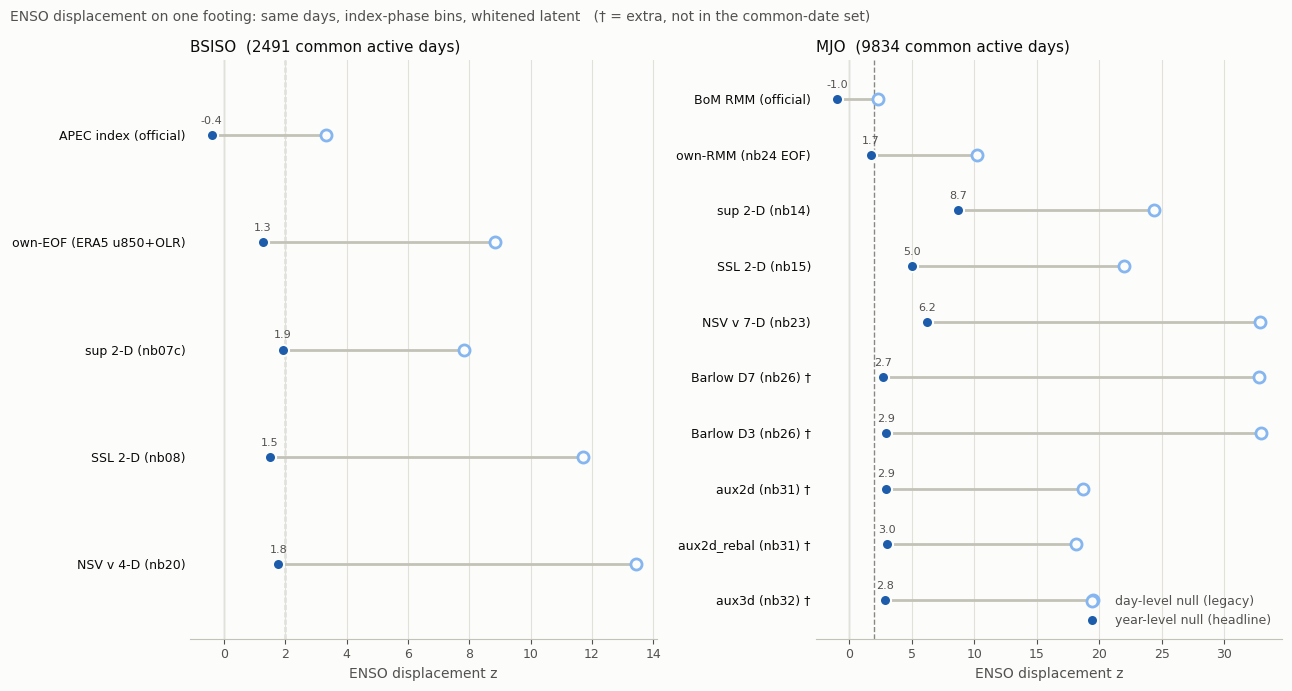

Saved enso_displacement_unified.png


In [18]:
C_DAY, C_YEAR = '#86b6ef', '#1c5cab'          # one hue, two shades (reference blue ramp steps 250 / 550)
INK, INK2, MUTED, GRID, BASE, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'

Hh = res[res.config == 'headline']
n_rows = max((Hh['mode'] == m).sum() for m in ['BSISO', 'MJO'])
fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * n_rows + 2.0), facecolor=SURF)
for ax, mode, common in zip(axes, ['BSISO', 'MJO'], [common_b, common_m]):
    h = Hh[Hh['mode'] == mode].iloc[::-1]
    y = np.arange(len(h))
    ax.set_facecolor(SURF)
    ax.axvline(0, color=BASE, lw=1, zorder=0)
    ax.axvline(2, color=MUTED, lw=1, ls='--', zorder=0)
    ax.hlines(y, h['z_day'], h['z_year'], color=BASE, lw=2, zorder=1)
    ax.plot(h['z_day'], y, 'o', ms=8, mfc=SURF, mec=C_DAY, mew=2, ls='none', zorder=2, label='day-level null (legacy)')
    ax.plot(h['z_year'], y, 'o', ms=8, mfc=C_YEAR, mec=SURF, mew=1.5, ls='none', zorder=3, label='year-level null (headline)')
    for yi, zy in zip(y, h['z_year']):
        ax.annotate(f'{zy:.1f}', (zy, yi), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color=INK2)
    ax.set_yticks(y)
    ax.set_yticklabels(h['rep'] + np.where(h['core'], '', ' †'), fontsize=9, color=INK)
    ax.set_ylim(-0.7, len(h) - 0.3)
    ax.grid(axis='x', color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ['top', 'right', 'left']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(BASE)
    ax.tick_params(axis='x', colors=INK2, labelsize=9); ax.tick_params(axis='y', length=0)
    ax.set_xlabel('ENSO displacement z', color=INK2)
    ax.set_title(f'{mode}  ({len(common)} common active days)', loc='left', fontsize=11, color=INK)
axes[1].legend(loc='lower right', frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle('ENSO displacement on one footing: same days, index-phase bins, whitened latent   († = extra, not in the common-date set)',
             x=0.01, ha='left', fontsize=10, color=INK2)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/enso_displacement_unified.png', dpi=150, bbox_inches='tight', facecolor=SURF)
plt.show()
print('Saved enso_displacement_unified.png')

---
## Done — what to send back

1. The printed output of **Cell 3** (self-test PASSED?), **Cell 5 / 6** (which files loaded, their dates, APEC phase
   agreement, own-EOF variance + canonical correlation), and **Cell 8** (the three tables).
2. `enso_displacement_unified.png`.

**How to read it.** Compare representations on **z_year** in the headline table. The gap to z_day shows how much of
each old z came from the day-level null. `ratio` is the effect size (it does not grow with N). If an index row
has a year-level z comparable to the learned latents, the learned latents do not capture more ENSO modulation
than the index does, once days, bins, units and the null are held fixed.